In [ ]:
# imports
import scipy.io
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matlab
import numpy as np

# Basic Python Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Deep Learning Librarys
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [24]:
# Load the .mat file
data = scipy.io.loadmat('Xtrain.mat')
# Inspect the keys 
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


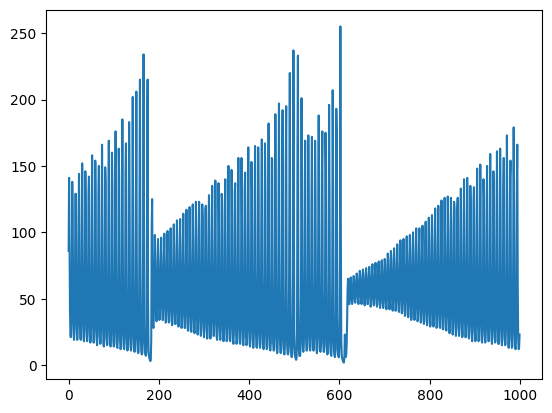

In [25]:
matlab.plot(data['Xtrain'])

In [ ]:
# reshape data

X_raw = data['Xtrain'].flatten()  # make 1D
print("Total samples:", len(X_raw))

Total samples: 1000


In [32]:
# create windows of data
window_size = 3
X, Y = [], []
for i in range(len(X_raw) - window_size):
    X.append(X_raw[i:i+window_size])
    Y.append(X_raw[i+window_size])  # next value as target
X, Y = np.array(X), np.array(Y)

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)


Shape of X: (997, 3)
Shape of Y: (997,)


In [33]:
# Reshape input to be [samples, time steps, features] which is required for RNN
X = X.reshape(X.shape[0], X.shape[1], 1)

X

array([[[ 86],
        [141],
        [ 95]],

       [[141],
        [ 95],
        [ 41]],

       [[ 95],
        [ 41],
        [ 22]],

       ...,

       [[166],
        [ 61],
        [ 20]],

       [[ 61],
        [ 20],
        [ 12]],

       [[ 20],
        [ 12],
        [ 13]]], shape=(997, 3, 1), dtype=uint8)

In [ ]:
# Build the RNN Model
model = Sequential()
# SimpleRNN Layer: The RNN layer has 20 units and uses the ReLU activation function. The input shape is specified as (time_step, 1).
model.add(SimpleRNN(20, activation="relu", input_shape=(time_step, 1)))
# Dense Layer: A fully connected Dense layer with 1 unit is added, which outputs the prediction.
model.add(Dense(1))
# Compilation: The model is compiled using the Adam optimizer and Mean Squared Error (MSE) loss function.
model.compile(optimizer="ADAM", loss="mse")